In [5]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn glob2 pyarrow matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------------------------- ------------- 5.5/8.3 MB 31.2 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 33.3 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 33.3 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 33.3 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 33.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.7 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 34.7 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 34.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 14.6 MB/s  0:00:00

   ----- -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: c:\Users\Dat\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import glob
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

# ==========================================
# LE THANH DAT (TASK 2.2)
# 1. TỔNG HỢP VÀ DỌN DẸP DỮ LIỆU 
# ==========================================

path = '../data/*.csv'
files = glob.glob(path)

# Nếu đã có file pkl rồi thì load luôn, không cần đọc lại 8 CSV
if os.path.exists('../models/cleaned_data.pkl'):
    print("Tìm thấy cleaned_data.pkl, đang load...")
    df = joblib.load('../models/cleaned_data.pkl')
    print("Load xong!")

elif not files:
    print("LỖI: Không tìm thấy file CSV nào trong thư mục data!")

else:
    # Gộp tất cả file thành 1 DataFrame lớn
    print(f"Đang gộp {len(files)} file dữ liệu...")
    df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    # 1. Dọn dẹp khoảng trắng tên cột
    df.columns = df.columns.str.strip()

    # Mapping từ tên cột thực tế (của bạn) sang tên cột yêu cầu (của Lab)
    column_mapping = {
        'Destination Port': 'Dst Port',
        'Total Fwd Packets': 'Tot Fwd Pkts',
        'Total Backward Packets': 'Tot Bwd Pkts',
        'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
        'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
        'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
        'Bwd Packet Length Mean': 'Bwd Pkt Len Mean',
        'Flow Bytes/s': 'Flow Byts/s',
        'Flow Packets/s': 'Flow Pkts/s',
        'Packet Length Mean': 'Pkt Len Mean',
        'Packet Length Std': 'Pkt Len Std',
        'FIN Flag Count': 'FIN Flag Cnt',
        'SYN Flag Count': 'SYN Flag Cnt',
        'RST Flag Count': 'RST Flag Cnt',
        'PSH Flag Count': 'PSH Flag Cnt',
        'ACK Flag Count': 'ACK Flag Cnt',
        'URG Flag Count': 'URG Flag Cnt'
    }

    df.rename(columns=column_mapping, inplace=True)
    print("Đã đồng bộ hóa tên cột theo yêu cầu Lab.")

    # 2. Loại bỏ dữ liệu trùng lặp trước (Giảm số hàng cần xử lý phía sau)
    print("Đang loại bỏ dữ liệu trùng lặp...")
    df.drop_duplicates(inplace=True)

    # 3. Xử lý giá trị vô hạn (inf)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 4. Điền các giá trị trống bằng trung vị (median)
    # Lưu ý: numeric_only=True là bắt buộc để tránh lỗi với cột Label (chữ)
    df.fillna(df.median(numeric_only=True), inplace=True)

    # 5. Loại bỏ các cột biến thiên bằng 0 (PHẢI GÁN LẠI BIẾN DF)
    print("Đang loại bỏ các cột zero-variance...")
    non_zero_var_cols = [col for col in df.columns if df[col].nunique() > 1]
    df = df[non_zero_var_cols] # <--- Cần dòng này để thực thi việc lọc

    # 6. Tối ưu RAM
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    # Lưu lại
    joblib.dump(df, '../models/cleaned_data.pkl')
    print(f"Hoàn thành! Số lượng cột còn lại: {df.shape[1]}")

Đang gộp 8 file dữ liệu...
Đã đồng bộ hóa tên cột theo yêu cầu Lab.
Đang loại bỏ dữ liệu trùng lặp...
Đang loại bỏ các cột zero-variance...
Hoàn thành! Số lượng cột còn lại: 71


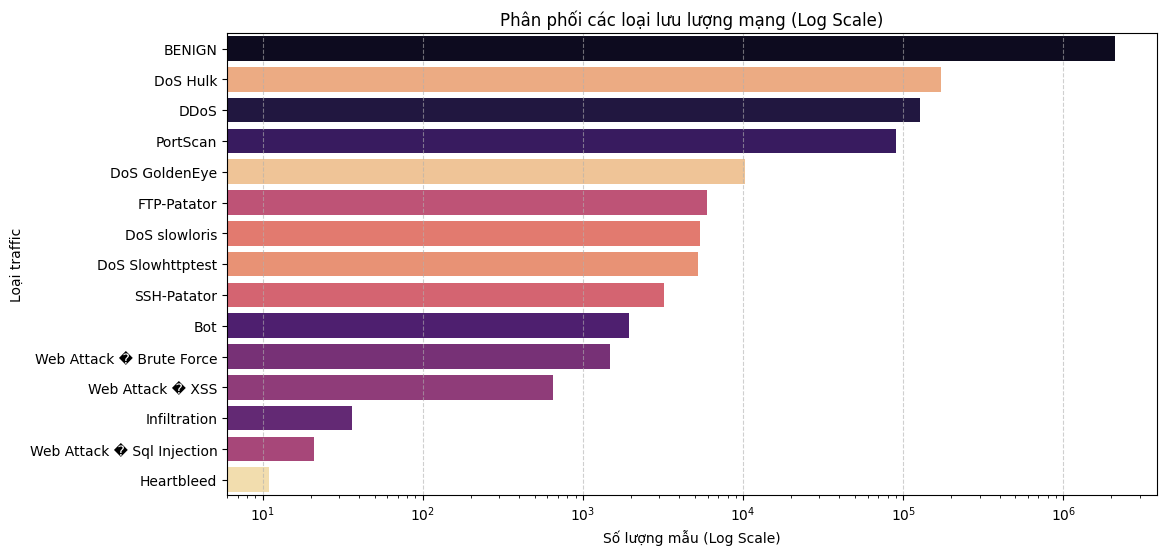

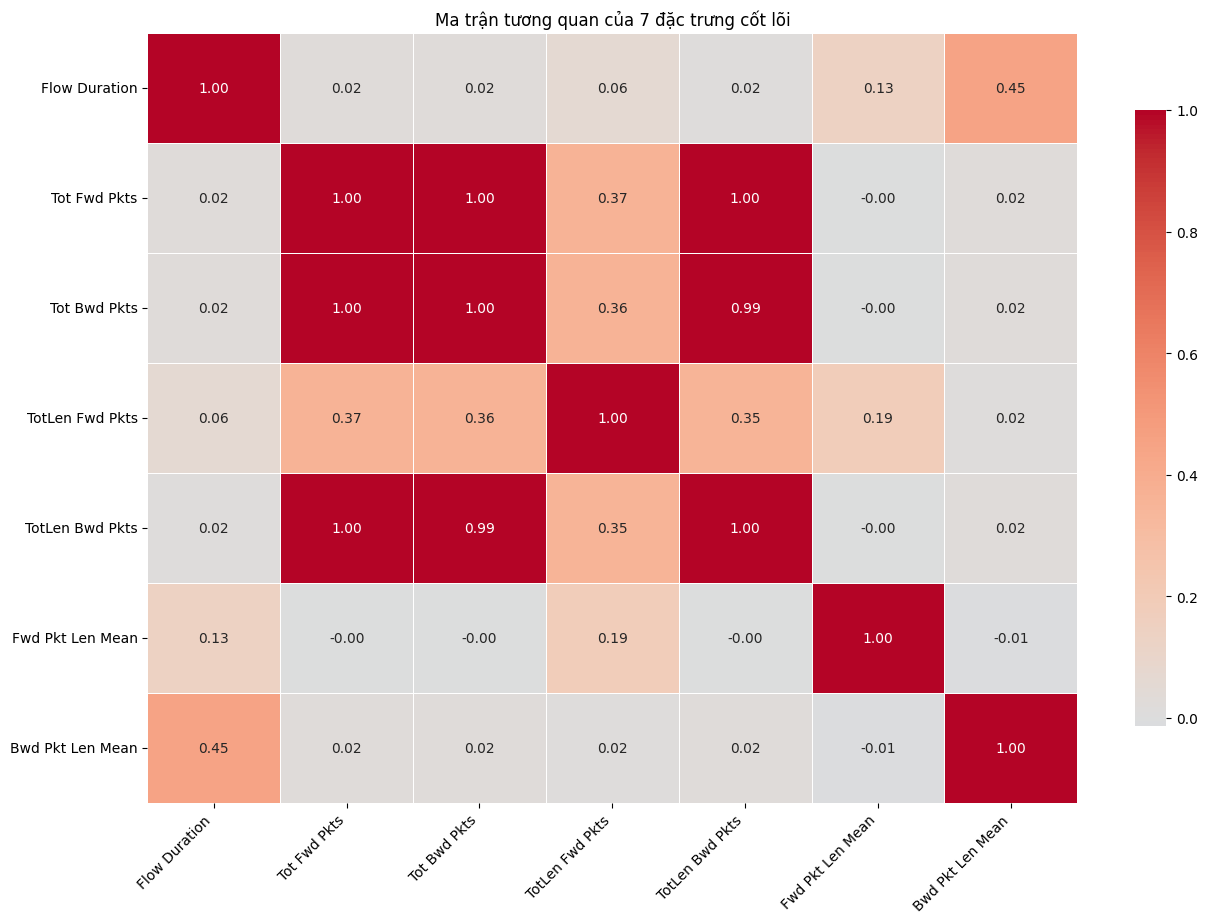

In [ ]:
# ==============================================================================
# TASK 2.2: EXPLORATORY DATA ANALYSIS (EDA)
# Mục tiêu: Thấu hiểu phân phối nhãn và mối tương quan giữa các đặc trưng cốt lõi.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PHÂN PHỐI NHÃN (TARGET DISTRIBUTION)
# Khắc phục FutureWarning bằng cách gán x/y và hue rõ ràng
plt.figure(figsize=(12, 6))
sns.countplot(
    y='Label', 
    data=df, 
    hue='Label',
    palette='magma', 
    order=df['Label'].value_counts().index,
    legend=False
)
plt.xscale('log') # Hiển thị rõ các lớp thiểu số như Heartbleed, Infiltration
plt.title('Phân phối các loại lưu lượng mạng (Log Scale)')
plt.xlabel('Số lượng mẫu (Log Scale)')
plt.ylabel('Loại traffic')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 2. MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP)
# Danh sách 18 đặc trưng cốt lõi theo yêu cầu 2.4
selected_features = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean',
    'Flow Byts/s', 'Flow Pkts/s', 'Pkt Len Mean', 'Pkt Len Std', 
    'SYN Flag Cnt', 'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt', 
    'PSH Flag Cnt', 'URG Flag Cnt'
]

# Tự động tìm tên cột thực tế (xử lý trường hợp dư khoảng trắng đầu/cuối)
actual_columns = {col.strip(): col for col in df.columns}
existing_features = [actual_columns[f] for f in selected_features if f in actual_columns]

if len(existing_features) > 1:
    plt.figure(figsize=(15, 10))
    # Tính toán ma trận tương quan
    corr = df[existing_features].corr()
    
    # Vẽ Heatmap với cấu hình chuẩn
    sns.heatmap(
        corr, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        center=0, 
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    plt.title(f'Ma trận tương quan của {len(existing_features)} đặc trưng cốt lõi')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print(f"CẢNH BÁO: Chỉ tìm thấy {len(existing_features)} cột. Kiểm tra lại df.columns!")
    print("Cột thực tế đang có:", df.columns.tolist()[:5], "...")

In [15]:
# ==========================================
# NGUYEN QUOC DAT 
# 2.3 XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
# ==========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import joblib

# Load df nếu chưa có
if 'df' not in dir():
    df = joblib.load('../models/cleaned_data.pkl')

# Encode Label
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print("Các nhãn:", list(le.classes_))

# Tách X (78 features), y
X = df.drop('Label', axis=1)
y = df['Label']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Xem phân phối trước
print("\nTrước khi balance:")
print(pd.Series(y_train).value_counts())

# SMOTE + RandomUnderSampler
majority_count = pd.Series(y_train).value_counts().max()
threshold = int(majority_count * 0.1)

sampling_strategy_smote = {
    cls: max(count, threshold)
    for cls, count in pd.Series(y_train).value_counts().items()
    if count < majority_count
}

pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=sampling_strategy_smote, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy='majority', random_state=42))
])

X_train, y_train = pipeline.fit_resample(X_train, y_train)

print("\nSau khi balance:")
print(pd.Series(y_train).value_counts())

# Lưu lại
joblib.dump((X_train, X_test, y_train, y_test), '../models/balanced_data.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("\nĐã lưu balanced_data.pkl!")

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# ==========================================
# LE THANH DAT (TASK 2.5)
# 2. HUẤN LUYỆN MÔ HÌNH BASELINE 
# ==========================================

# Mã hóa nhãn (Chuyển tên cuộc tấn công thành số)
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

# Chia đặc trưng (X) và nhãn mục tiêu (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Scaling) - Cực kỳ quan trọng cho Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình Logistic Regression
# Tăng max_iter để đảm bảo mô hình hội tụ tốt hơn
print("Đang huấn luyện mô hình Logistic Regression (có thể mất vài phút)...")
model = LogisticRegression(max_iter=500, solver='lbfgs')
model.fit(X_train_scaled, y_train)

# ==========================================
# 3. ĐÁNH GIÁ VÀ LƯU TRỮ (OUTPUT)
# ==========================================

# Tính toán độ chính xác tổng quát
accuracy = model.score(X_test_scaled, y_test)
print(f"\n--- KẾT QUẢ ---")
print(f"Độ chính xác tổng thể: {accuracy:.4f}")

# Dự đoán và in báo cáo chi tiết (Precision, Recall, F1-score)
y_pred = model.predict(X_test_scaled)
print("\nBáo cáo chi tiết cho từng loại tấn công:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Tạo thư mục và lưu trữ model đã học
joblib.dump(model, '../models/logistic_regression.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("\nĐã lưu 'logistic_regression.pkl' và 'scaler.pkl' vào thư mục models.")